In [2]:
import os
os.environ["ESMFMKFILE"] = "/home/mauracd/esmf/lib/libO/Linux.gfortran.64.openmpi.default/esmf.mk"

import numpy as np
import xarray as xr
import pandas as pd
import xesmf as xe
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from meteor import MeteorInterface
import random
import regionmask
import glob

/home/mauracd/METEOR/venv/lib/python3.13/site-packages/esmpy/interface/loadESMF_helpers.py:45: VersionWarning: You are using development versions of ESMF and ESMPy; we cannot verify if these versions are compatible
  warnings.warn("You are using development versions of ESMF and ESMPy; "


FASTMIP Phase 2: \
5 Tier 1 ESMs, 20 Tier 2 ESMs, and 4 scenarios. 

Train METEOR for given ESM list. 

For each combo of ESM+scenario: 
1. Generate 10 METEOR realization scaled to each of 20 randomly selected FAIR ensemble members. 
2. Regrid monthly output to common 2.5x2.5 grid. 
3. Generate FastMIP output files: 
- 10 member monthly gridded tas and pr per model 
- grid-wise mean and quantiles per model 
- grid-wise mean and quantiles across all Tier models 
- regional means and quantiles per model (AR6 regions, land only)
- regional means and quantiles across models (AR6 regions, land only) 
- regional uncertainties across models (var_scenario: variance due to scenario uncertainty, var_esm: variance due to ESM uncertainty, var_glob: variance due to global response uncertainty, var_int: variance due to internal variability)

To run this notebook you need some extra things besides METEOR:
- FAIR FASTMIP phase 2 forced ensemble (climate_assessment_forced.csv)
- region aggregation script (aggregate_to_regions.py)
- scenario input data (emissions and concentrations for SCM)
- xesmf installed in the virtual environment


In [ ]:
# SETUP

# FASTMIP Phase 2 ESMs:
ESMs_Tier1 = ['ACCESS-ESM1-5', 'CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'MIROC6']
ESMs_Tier2 = ['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CanESM5-1', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'EC-Earth3', 'FGOALS-g3', 'FIO-ESM-2-0', 'GFDL-ESM4', 'GISS-E2-1-G', 'HadGEM3–GC31-LL', 'HadGEM3–GC31-MM', 'MIROC-ES2L', 'MRI-ESM2-0', 'NorESM2-LM', 'UKESM1-0-LL', 'MPI-ESM1-2-HR']

# scenarios:
scenarios = ['Low - SSP2 (Marker)','Medium - SSP2 (Marker)','High - SSP3 (Marker)','Very Low - SSP1 (Marker)']
scenarios_short = ['L','M','H','VL']

# FAIR ensemble samples:
FAIRens = pd.read_csv('../data/FASTMIP_phase2/FAIR_data/climate_assessment_forced.csv')
random.seed()
num_fair = 20

# METEOR setup:
start_year = 2015
end_year = 2100
n_members = 10 # Meteor realizations per FAIR ensemble member
emiss_dir = '../data/FASTMIP_phase2/scenario_data/'

# for testing, run through smaller lists:
ESM_list = ['ACCESS-ESM1-5', 'CanESM5']
scenario_list = scenarios

# check if output directories exist, if not, create them:
output_dir = '../data/FASTMIP_phase2/METEOR_emulations/raw/'
aggregate_dir = '../data/FASTMIP_phase2/METEOR_emulations/aggregated/'
processed_dir = '../data/FASTMIP_phase2/METEOR_emulations/processed/'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
if not os.path.exists(aggregate_dir):
    os.makedirs(aggregate_dir)
if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)


In [4]:
# SOME UTILS

def save_if_not_exists(dataset, filename):
    if not os.path.exists(filename):
        dataset.to_netcdf(filename)
        print(f"File created: {filename}")
    else:
        print(f"File already exists, skipping: {filename}")

# get esm name file path and add as coordinates to dataset
def add_coords(ds):
    filename = os.path.basename(ds.encoding["source"])
    esm_str = filename.split('_')[1]
    return ds.expand_dims(esm=[esm_str])

# calculate AR6 regional means (re-written from provided aggregate_to_regions.py).
def compute_regional_means(base_ds):
    lat = base_ds["lat"]
    lon = base_ds["lon"]
    ar6=regionmask.defined_regions.ar6.land
    ar6_mask=ar6.mask(base_ds.lat, base_ds.lon)
    weights = np.cos(np.deg2rad(lat))
    weights.name = "area_weight"
    weights_expanded = weights.expand_dims(lon=lon).transpose("lon", "lat")

    da_ar6 = (base_ds*weights).groupby(ar6_mask).mean(dim=['stacked_lon_lat']) / weights_expanded.groupby(ar6_mask).mean(dim='stacked_lon_lat')

    da_global = base_ds.weighted(weights).mean(dim=['lon', 'lat']).expand_dims(mask=[-1])

    da_regions = xr.concat([da_ar6, da_global], dim="mask")

    flag_values = np.concatenate([ar6.numbers, [-1]])
    flag_meanings = " ".join(ar6.names + ["GLOBAL"])

    da_regions["mask"].attrs = {
        "standard_name": "region",
        "flag_values": flag_values,
        "flag_meanings": flag_meanings,
    }

    return da_regions



In [6]:
# train METEOR for list of ESMs (uses cached models if available)
# and generate annual gridded output scaled to randomly selected FAIR ensemble members (number set by num_fair above).

for esm in ESM_list:
    print(f"Creating emulator for {esm}...")
    emulator = MeteorInterface(
        model=esm,
        variables=['tas', 'pr'],
        cache_dir='../cache'
    )
   
    print(f"Training emulator for {emulator.model}...")
    emulator.train(verbose=False)

    # For each scenario, generate METEOR realizations scaled to randomly selected FAIR GSAT timeseries
    for s_idx,scenario in enumerate(scenario_list):
        print(f"Emulating scenario {scenario}...")

        # Construct emissions and concentrations dict
        emissions_path = f"{emiss_dir}scen7-{scenarios_short[s_idx]}_em_gases_vupdate_2022_AR6.txt"
        concentrations_path = f"{emiss_dir}scen7-{scenarios_short[s_idx]}_conc_gases_vupdate_2022_AR6.txt"
        scenario_dict = {'emissions': emissions_path, 'concentrations': concentrations_path}

        # Get FAIR samples
        FAIRens_sample = FAIRens[(FAIRens['scenario'] == scenario) & (FAIRens['variable'] == 'Climate Assessment|Surface Temperature (GSAT)')].sample(num_fair, replace=False)

        # Loop through FAIR ensemble members and create METEOR realizations
        for fair_mem in FAIRens_sample.index:

            # Extract the GSAT timeseries for this member
            scaling_ts = FAIRens_sample.loc[fair_mem, str(start_year):str(end_year)].rename(int).to_xarray().rename('tas').rename({'index':'year'})

            # Create METEOR noise realizations scaled to this FAIR member's GSAT timeseries:
            ensemble_scaled = emulator.generate_ensemble_outputs(
                scenario=scenario_dict,
                start_year=start_year,
                end_year=end_year,
                n_realizations=n_members,
                timeseries=['global'], 
                gridded={'annual': list(range(start_year, end_year + 1))},
                temp_scaling_ts=scaling_ts,
                save_to=f"{output_dir}METEOR_{esm}_{scenarios_short[s_idx]}_scaledtoFAIRens_{fair_mem}.nc"
            ) 

Creating emulator for ACCESS-ESM1-5...
Training emulator for ACCESS-ESM1-5...
🔧 Preparing pattern scaling training data for ACCESS-ESM1-5...
   ✅ Training data prepared for experiments:  ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-ACCESS-ESM1-5-aer-tas_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-ACCESS-ESM1-5-aer-tas_pattern_scaling.pkl
Model loaded from ../cache/noise_models/ACCESS-ESM1-5_tas_noise_model.pkl
🔧 Preparing pattern scaling training data for ACCESS-ESM1-5...
   ✅ Training data prepared for experiments:  ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Config: 1750-2100, emissions start:

/home/mauracd/METEOR/src/meteor/meteor_interface.py:934: RuntimeWarning: invalid value encountered in divide
  temperature_input_anomaly.values / annual_temp_prediction_gm_anomaly.values,


      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 10 stochastic PC realizations...
      • global
   → Gridded outputs...
      → Computing pattern scaling for tas, custom scenario 'custom'...
      → Loaded emissions from scen7-L_em_gases_vupdate_2022_AR6.txt
      → Loaded concentrations from scen7-L_conc_gases_vupdate_2022_AR6.txt
 Ts scaleing before calculating annual pred <xarray.DataArray 'year' (year: 86)> Size: 688B
array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026,
       2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038,
       2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050,
       2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062,
       2063, 2064, 2065, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074,
       2075, 2076, 2077, 2078, 2079, 2080, 2081, 

/home/mauracd/METEOR/src/meteor/meteor_interface.py:934: RuntimeWarning: invalid value encountered in divide
  temperature_input_anomaly.values / annual_temp_prediction_gm_anomaly.values,


      → Generating 10 gridded realizations
      → Extracting annual means for 86 years
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12

...

/home/mauracd/METEOR/src/meteor/meteor_interface.py:934: RuntimeWarning: invalid value encountered in divide
  temperature_input_anomaly.values / annual_temp_prediction_gm_anomaly.values,


      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 10 stochastic PC realizations...
      • global
   → Gridded outputs...
      → Computing pattern scaling for tas, custom scenario 'custom'...
      → Loaded emissions from scen7-L_em_gases_vupdate_2022_AR6.txt
      → Loaded concentrations from scen7-L_conc_gases_vupdate_2022_AR6.txt
 Ts scaleing before calculating annual pred <xarray.DataArray 'year' (year: 86)> Size: 688B
array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026,
       2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038,
       2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050,
       2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062,
       2063, 2064, 2065, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074,
       2075, 2076, 2077, 2078, 2079, 2080, 2081, 

/home/mauracd/METEOR/src/meteor/meteor_interface.py:934: RuntimeWarning: invalid value encountered in divide
  temperature_input_anomaly.values / annual_temp_prediction_gm_anomaly.values,


      → Generating 10 gridded realizations
      → Extracting annual means for 86 years
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12

KeyboardInterrupt: 

In [ ]:
# Regrid to common grid and combine outputs into single files for each scenario.
# If multiple METEOR noise realizations were generated per FAIR ensemble member, an extra dimension is added called 'noise realisation'.

xsize    = 144
ysize    = 72
xfirst   = 1.25
xinc     = 2.5
yfirst   = -88.75
yinc     = 2.5

def regrid_to_common_grid(ds):
    ds_out = xe.util.cf_grid_2d(
    lon0_b=xfirst, lon1_b=xfirst + xsize*xinc, d_lon=xinc,
    lat0_b=yfirst, lat1_b=yfirst + ysize*yinc, d_lat=yinc)

    regridder = xe.Regridder(ds, ds_out, "conservative")
    return regridder(ds)

# get all ESMs for a scenario, concatenate along fair_realisation dimension then ESM, regrid to common grid, and save to new file:
for s_idx, scenario in enumerate(scenario_list):
    files = []
    for esm in ESM_list:
        files_sub = glob.glob(f"{output_dir}METEOR_{esm}_{scenarios_short[s_idx]}_scaledtoFAIRens_*.nc")
        files.append(files_sub)

    combined_ds = xr.open_mfdataset(files, concat_dim=['esm','fair_realisation'], combine='nested', preprocess=add_coords).rename({'realization':'noise_realisation','tas_grid_annual':'tas', 'pr_grid_annual':'pr'})
    combined_ds_regridded = regrid_to_common_grid(combined_ds)
    file_name = f"{aggregate_dir}METEOR_{scenarios_short[s_idx]}_scaledtoFAIR_combinedESMs_regridded.nc"
    save_if_not_exists(combined_ds_regridded, file_name)

/home/mauracd/METEOR/venv/lib/python3.13/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


## GENERATE FastMIP outputs:

In [ ]:
# 10 Ensemble member gridded data:
# Split tas and pr to seperate files. 
# Randomly select 10 members across both 'fair_realisation' (FAIR) and 'noise_realisation' (METEOR noise) dimensions.

aggregation = 'gridcell'
quantity = 'selected-realisations'

for s_idx, scenario in enumerate(scenario_list):
    # get all the data for this scenario (all ESMs, all FAIR and noise realisations):
    base_ds = xr.open_dataset(f"{aggregate_dir}METEOR_{scenarios_short[s_idx]}_scaledtoFAIR_combinedESMs_regridded.nc")
    # stack the realisation dimensions to make it easier to select random members across both dimensions:
    data_stacked = base_ds.stack(realisation=['noise_realisation', 'fair_realisation'])
    # randomly select 10 members across both dimensions:
    if data_stacked.sizes['realisation'] > 1:
        rand_index = random.sample(range(data_stacked.sizes['realisation']), 10)
        subset_data = data_stacked.isel(realisation=rand_index)
    # save tas and pr to separate files:
    subset_data['tas'].to_netcdf(f"{processed_dir}tas_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")
    subset_data['pr'].to_netcdf(f"{processed_dir}pr_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")


In [ ]:
# FastMIP outputs per ESM (gridwise mean and quantiles).
# These are calculated using all the METEOR noise realisations.
quantity = 'quantiles-by-ESM'
aggregation = 'gridcell'

# gridwise mean and quantiles:
quantile_list = [0.01, 0.025, 0.05, 0.33, 0.5, 0.67, 0.95, 0.975, 0.99] # 1%, 2.5%, 5%, 33%, median, 67%, 95%, 97.5%, 99%

for s_idx, scenario in enumerate(scenario_list):
    base_ds = xr.open_dataset(f"{aggregate_dir}METEOR_{scenarios_short[s_idx]}_scaledtoFAIR_combinedESMs_regridded.nc")

    # calculate gridwise means and quantiles:
    mean_ds = base_ds.mean(dim=['fair_realisation', 'noise_realisation']).rename({'tas':'tas_mean', 'pr':'pr_mean'})
    quantiles_ds = base_ds.quantile(quantile_list, dim=['fair_realisation', 'noise_realisation'])

    # save tas and pr to separate files:
    tas_ds = xr.merge([mean_ds['tas_mean'], quantiles_ds['tas']])
    pr_ds = xr.merge([mean_ds['pr_mean'], quantiles_ds['pr']])
    tas_ds.to_netcdf(f"{processed_dir}tas_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")
    pr_ds.to_netcdf(f"{processed_dir}pr_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")

In [ ]:
# FastMIP outputs per ESM (regional mean and quantiles).
# These are calculated using all the METEOR noise realisations.
quantity = 'quantiles-by-ESM'
aggregation = 'regional'


for s_idx, scenario in enumerate(scenario_list):
    base_ds = xr.open_dataset(f"{aggregate_dir}METEOR_{scenarios_short[s_idx]}_scaledtoFAIR_combinedESMs_regridded.nc")

    # aggregate to regional level, than calculate statistics:
    regional_means = compute_regional_means(base_ds)
    mean_ds = regional_means.mean(dim=['fair_realisation', 'noise_realisation']).rename({'tas':'tas_mean', 'pr':'pr_mean'})
    quantiles_ds = regional_means.quantile(quantile_list, dim=['fair_realisation', 'noise_realisation'])

    # save tas and pr to separate files:
    tas_ds = xr.merge([mean_ds['tas_mean'], quantiles_ds['tas']])
    pr_ds = xr.merge([mean_ds['pr_mean'], quantiles_ds['pr']])
    tas_ds.to_netcdf(f"{processed_dir}tas_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")
    pr_ds.to_netcdf(f"{processed_dir}pr_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")


In [ ]:
# FastMIP outputs across ESMs (gridwise mean and quantiles).
# These are calculated using all the METEOR noise realisations.
quantity = 'quantiles-across-ESM'
aggregation = 'gridcell'

# gridwise mean and quantiles:
quantile_list = [0.01, 0.025, 0.05, 0.33, 0.5, 0.67, 0.95, 0.975, 0.99] # 1%, 2.5%, 5%, 33%, median, 67%, 95%, 97.5%, 99%

#for esm in ESM_list:
for s_idx, scenario in enumerate(scenario_list):
    base_ds = xr.open_dataset(f"{aggregate_dir}METEOR_{scenarios_short[s_idx]}_scaledtoFAIR_combinedESMs_regridded.nc")

    # calculate and save gridwise quantiles:
    mean_ds = base_ds.mean(dim=['fair_realisation', 'noise_realisation', 'esm']).rename({'tas':'tas_mean', 'pr':'pr_mean'})
    quantiles_ds = base_ds.quantile(quantile_list, dim=['fair_realisation', 'noise_realisation', 'esm'])

    # save tas and pr to separate files:
    tas_ds = xr.merge([mean_ds['tas_mean'], quantiles_ds['tas']])
    pr_ds = xr.merge([mean_ds['pr_mean'], quantiles_ds['pr']])
    tas_ds.to_netcdf(f"{processed_dir}tas_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")
    pr_ds.to_netcdf(f"{processed_dir}pr_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")

In [ ]:
# FastMIP outputs across ESMs (regional mean and quantiles).
# These are calculated using all the METEOR noise realisations.
quantity = 'quantiles-across-ESM'
aggregation = 'regional'

for s_idx, scenario in enumerate(scenario_list):
    base_ds = xr.open_dataset(f"{aggregate_dir}METEOR_{scenarios_short[s_idx]}_scaledtoFAIR_combinedESMs_regridded.nc")

    # aggregate to regional level, than calculate statistics:
    regional_means = compute_regional_means(base_ds)
    mean_ds = regional_means.mean(dim=['fair_realisation', 'noise_realisation', 'esm']).rename({'tas':'tas_mean', 'pr':'pr_mean'})
    quantiles_ds = regional_means.quantile(quantile_list, dim=['fair_realisation', 'noise_realisation', 'esm'])

    # save tas and pr to separate files:
    tas_ds = xr.merge([mean_ds['tas_mean'], quantiles_ds['tas']])
    pr_ds = xr.merge([mean_ds['pr_mean'], quantiles_ds['pr']])
    tas_ds.to_netcdf(f"{processed_dir}tas_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")
    pr_ds.to_netcdf(f"{processed_dir}pr_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")

In [ ]:
# FastMIP uncertainty decomposition by region, per scenario.
aggregation = 'regional'
quantity = 'uncertainty'

for s_idx, scenario in enumerate(scenario_list):
    base_ds = xr.open_dataset(f"{aggregate_dir}METEOR_{scenarios_short[s_idx]}_scaledtoFAIR_combinedESMs_regridded.nc")

    regional_means = compute_regional_means(base_ds)
    var_esm = regional_means.mean(dim='noise_realisation').var(dim='esm').mean(dim='fair_realisation')
    var_glb = regional_means.mean(dim='noise_realisation').var(dim='fair_realisation').mean(dim='esm')
    var_int = regional_means.var(dim='noise_realisation').mean(dim=['esm', 'fair_realisation'])

    # save tas and pr to separate files:
    tas_var = xr.merge([var_esm['tas'].rename('var_esm'), var_glb['tas'].rename('var_glb'), var_int['tas'].rename('var_int')])
    pr_var = xr.merge([var_esm['pr'].rename('var_esm'), var_glb['pr'].rename('var_glb'), var_int['pr'].rename('var_int')])
    tas_var.to_netcdf(f"{processed_dir}tas_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")
    pr_var.to_netcdf(f"{processed_dir}pr_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")

In [ ]:
# FastMIP uncertainty decomposition by region, across scenarios.
aggregation = 'regional'
quantity = 'across-scenario-uncertainty'

# combine all scenarios:
base_ds_list = []
for s_idx, scenario in enumerate(scenario_list):
    base_ds = xr.open_dataset(f"{aggregate_dir}METEOR_{scenarios_short[s_idx]}_scaledtoFAIR_combinedESMs_regridded.nc")
    base_ds_list.append(base_ds)
combined_ds = xr.concat(base_ds_list, dim='scenario', coords='minimal')

# aggregate to regional level, than calculate variance components:
regional_means = compute_regional_means(combined_ds)

var_int = regional_means.var(dim='noise_realisation').mean(dim=['esm', 'fair_realisation', 'scenario'])
var_glb = regional_means.mean(dim='noise_realisation').var(dim=['fair_realisation']).mean(dim=['esm', 'scenario'])
var_esm = regional_means.mean(dim='noise_realisation').var(dim=['esm']).mean(dim=['fair_realisation', 'scenario'])
var_scenario = regional_means.mean(dim='noise_realisation').var(dim='scenario').mean(dim=['esm', 'fair_realisation'])

# save tas and pr to separate files:
tas_var = xr.merge([var_int['tas'].rename('var_int'), var_glb['tas'].rename('var_glb'), var_esm['tas'].rename('var_esm'), var_scenario['tas'].rename('var_scenario')])
pr_var = xr.merge([var_int['pr'].rename('var_int'), var_glb['pr'].rename('var_glb'), var_esm['pr'].rename('var_esm'), var_scenario['pr'].rename('var_scenario')])
tas_var.to_netcdf(f"{processed_dir}tas_cross-scenario_METEOR_{aggregation}_{quantity}.nc")
pr_var.to_netcdf(f"{processed_dir}pr_cross-scenario_METEOR_{aggregation}_{quantity}.nc")

In [ ]:
#FastMIP uncertainty decomposition gridwise, per scenario.
aggregation = 'gridcell'
quantity = 'uncertainty'

for s_idx, scenario in enumerate(scenario_list):
    base_ds = xr.open_dataset(f"{aggregate_dir}METEOR_{scenarios_short[s_idx]}_scaledtoFAIR_combinedESMs_regridded.nc")

    var_esm = base_ds.mean(dim='noise_realisation').var(dim='esm').mean(dim='fair_realisation')
    var_glb = base_ds.mean(dim='noise_realisation').var(dim='fair_realisation').mean(dim='esm')
    var_int = base_ds.var(dim='noise_realisation').mean(dim=['esm', 'fair_realisation'])

    # save tas and pr to separate files:
    tas_var = xr.merge([var_esm['tas'].rename('var_esm'), var_glb['tas'].rename('var_glb'), var_int['tas'].rename('var_int')])
    pr_var = xr.merge([var_esm['pr'].rename('var_esm'), var_glb['pr'].rename('var_glb'), var_int['pr'].rename('var_int')])
    tas_var.to_netcdf(f"{processed_dir}tas_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")
    pr_var.to_netcdf(f"{processed_dir}pr_{scenarios_short[s_idx]}_METEOR_{aggregation}_{quantity}.nc")

In [ ]:
# FastMIP uncertainty decomposition gridwise, across scenarios.
aggregation = 'gridcell'
quantity = 'across-scenario-uncertainty'

# combine all scenarios:
base_ds_list = []
for s_idx, scenario in enumerate(scenario_list):
    base_ds =  xr.open_dataset(f"{aggregate_dir}METEOR_{scenarios_short[s_idx]}_scaledtoFAIR_combinedESMs_regridded.nc")
    base_ds_list.append(base_ds)
combined_ds = xr.concat(base_ds_list, dim='scenario', coords='minimal')

var_int = combined_ds.var(dim='noise_realisation').mean(dim=['esm', 'fair_realisation', 'scenario'])
var_glb = combined_ds.mean(dim='noise_realisation').var(dim=['fair_realisation']).mean(dim=['esm', 'scenario'])
var_esm = combined_ds.mean(dim='noise_realisation').var(dim=['esm']).mean(dim=['fair_realisation', 'scenario'])
var_scenario = combined_ds.mean(dim='noise_realisation').var(dim='scenario').mean(dim=['esm', 'fair_realisation'])

# save tas and pr to separate files:
tas_var = xr.merge([var_int['tas'].rename('var_int'), var_glb['tas'].rename('var_glb'), var_esm['tas'].rename('var_esm'), var_scenario['tas'].rename('var_scenario')])
pr_var = xr.merge([var_int['pr'].rename('var_int'), var_glb['pr'].rename('var_glb'), var_esm['pr'].rename('var_esm'), var_scenario['pr'].rename('var_scenario')])
tas_var.to_netcdf(f"{processed_dir}tas_cross-scenario_METEOR_{aggregation}_{quantity}.nc")
pr_var.to_netcdf(f"{processed_dir}pr_cross-scenario_METEOR_{aggregation}_{quantity}.nc")

## plots (as in example notebook - https://github.com/sarasita/fastMIP/blob/main/requested_output/tour_through_requested_output.ipynb)

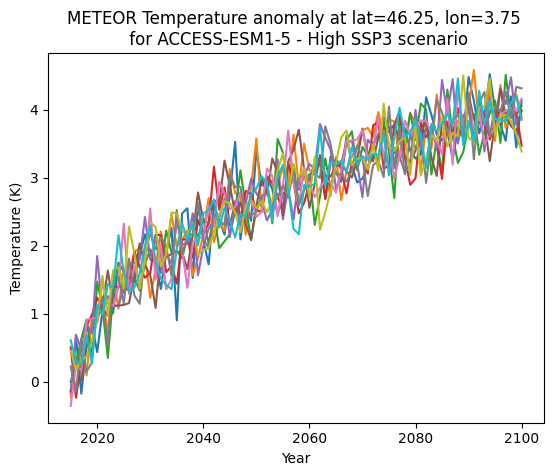

In [ ]:
# plot ensemble timeseries for a given point:
tas = xr.open_dataset(f"{processed_dir}/tas_H_METEOR_gridcell_selected-realisations.nc")
model = 'ACCESS-ESM1-5'
sel_lat = 46.25
sel_lon = 3.75

plt.figure()
plt.plot(tas['year'].values, tas['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, method='nearest').values.T)
plt.xlabel('Year')
plt.ylabel('Temperature (K)') 
plt.title(f'METEOR Temperature anomaly at lat={sel_lat}, lon={sel_lon} \n for {model} - High SSP3 scenario')
plt.show()
plt.savefig(f"../figures/METEOR_{model}_{scenarios_short[s_idx]}_tasanom_{sel_lat}_{sel_lon}.png")

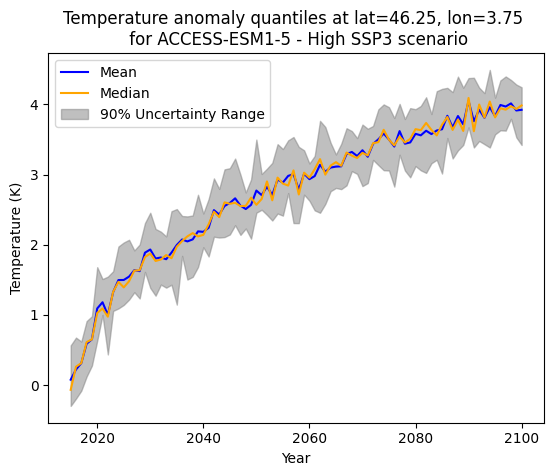

In [ ]:
# plotting the median and mean temperature anomaly
# along with the 90% uncertainty range for the selected grid-cell
example_data = xr.open_dataset(f"{processed_dir}/tas_H_METEOR_gridcell_quantiles-by-ESM.nc")
model = 'ACCESS-ESM1-5'

sel_lat = 46.25
sel_lon = 3.75

plt.figure()
plt.plot(example_data['year'].values, example_data['tas_mean'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, method='nearest').values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.5, method='nearest').values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.05, method='nearest').values.squeeze(),
                 example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.95, method='nearest').values.squeeze(),
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')  # Assuming the data is temperature in Kelvin
plt.title(f'Temperature anomaly quantiles at lat={sel_lat}, lon={sel_lon} \n for {model} - High SSP3 scenario')
plt.legend()
plt.show()
plt.savefig(f"../figures/METEOR_{model}_{scenarios_short[s_idx]}_tasanom_quantiles_{sel_lat}_{sel_lon}.png")

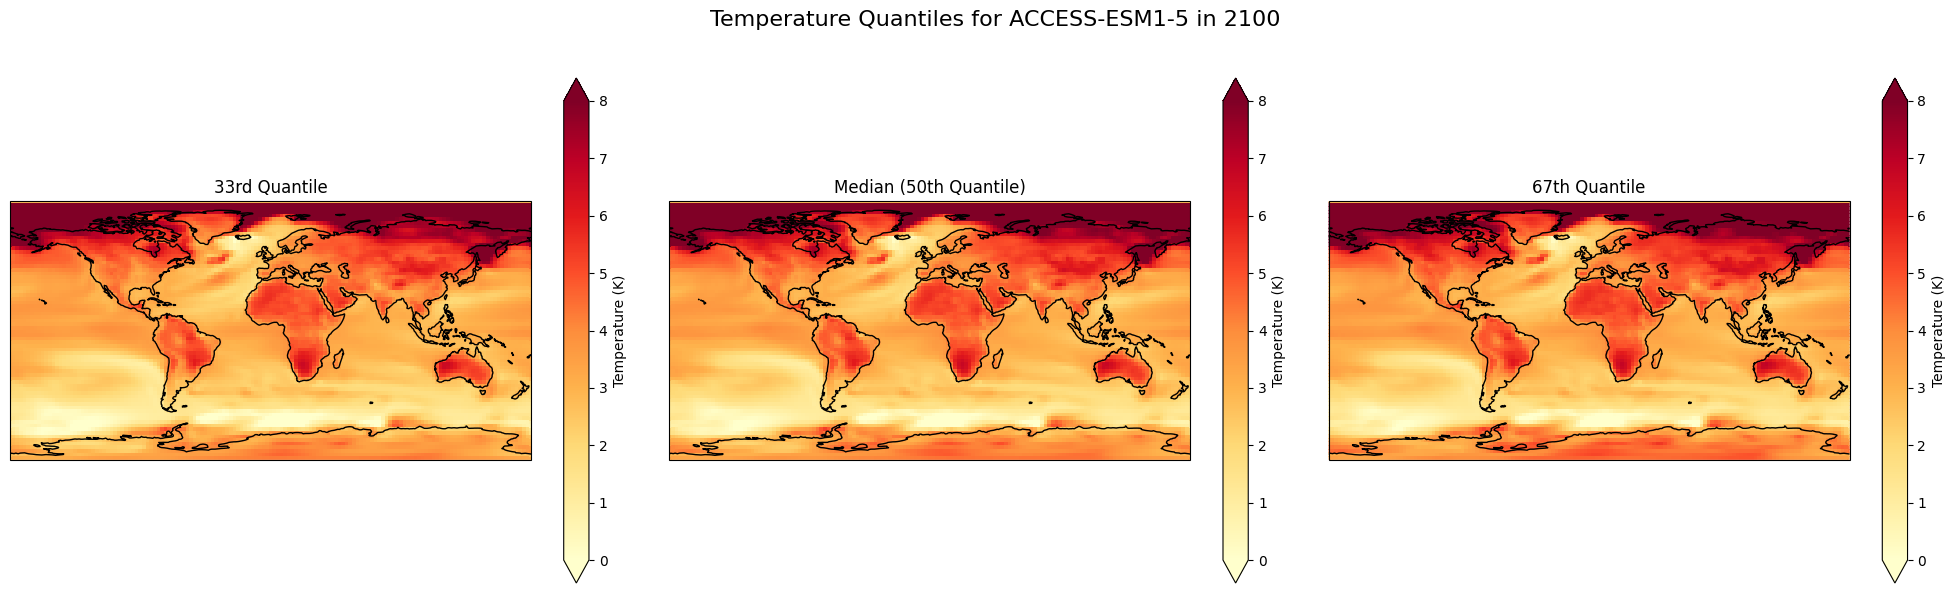

In [ ]:
# Generate maps for the 33rd, median, and 67th quantiles for the selected ESM and year 2100

quantiles_to_plot = [0.33, 0.5, 0.67]
titles = ['33rd Quantile', 'Median (50th Quantile)', '67th Quantile']
cmap = 'YlOrRd'

fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, quantile, title in zip(axes, quantiles_to_plot, titles):
    data = example_data['tas'].sel(quantile=quantile, esm=model, year=2100)
    data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        cbar_kwargs={"label": "Temperature (K)"},
        vmin = 0,
        vmax = 8
    )
    ax.coastlines()
    ax.set_title(title)

fig.suptitle(f'Temperature Quantiles for {model} in 2100 - High SSP3 scenario', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the suptitle
plt.show()
plt.savefig(f"../figures/METEOR_{model}_{scenarios_short[s_idx]}_tasanom_quantile_maps_2100.png")

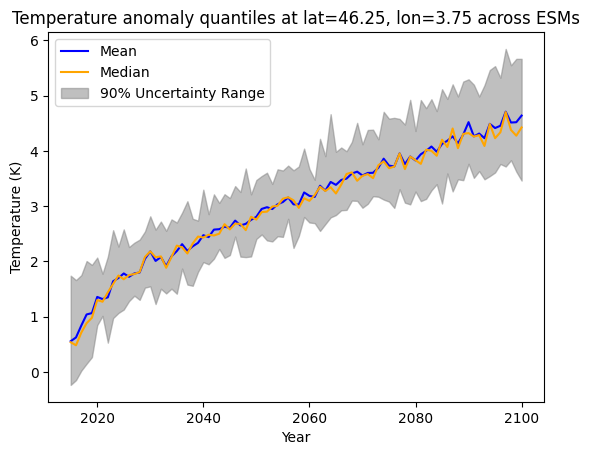

In [ ]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range computed across ESMs
# for the selected grid-cell
example_data = xr.open_dataset(f"{processed_dir}/tas_H_METEOR_gridcell_quantiles-across-ESM.nc")
plt.figure()
plt.plot(example_data['year'].values, example_data['tas_mean'].sel(lat=sel_lat, lon=sel_lon, method='nearest').values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data['tas'].sel(lat=sel_lat, lon=sel_lon, quantile=0.5, method='nearest').values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data['tas'].sel(lat=sel_lat, lon=sel_lon, quantile=0.05, method='nearest').values,
                 example_data['tas'].sel(lat=sel_lat, lon=sel_lon, quantile=0.95, method='nearest').values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')  # Assuming the data is temperature in Kelvin
plt.title(f'Temperature anomaly quantiles at lat={sel_lat}, lon={sel_lon} across ESMs - High SSP3 scenario')
plt.legend()
plt.show()
plt.savefig(f"../figures/METEOR_cross-ESM_{scenarios_short[s_idx]}_tasanom_quantiles_{sel_lat}_{sel_lon}.png")

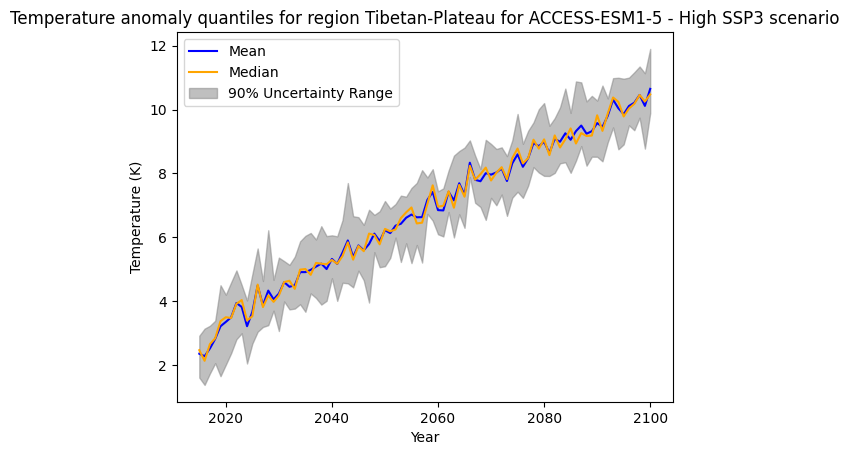

In [ ]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range for a selected region
# and ESM
example_data = xr.open_dataset(f"{processed_dir}/tas_H_METEOR_regional_quantiles-by-ESM.nc")
selected_regions = [-1, 34, 17]
sel_mask = selected_regions[1]  # selecting a region
region_name = regionmask.defined_regions.ar6.land[sel_mask].name # getting the name of the region

plt.figure()
plt.plot(example_data['year'].values, example_data['tas_mean'].sel(mask = sel_mask, esm = model ).values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data['tas'].sel(mask = sel_mask, quantile=0.5, esm = model ).values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data['tas'].sel(mask = sel_mask, quantile=0.05, esm = model ).values,
                 example_data['tas'].sel(mask = sel_mask, quantile=0.95, esm = model ).values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')  # Assuming the data is temperature in Kelvin
plt.title(f'Temperature anomaly quantiles for region {region_name} for {model} - High SSP3 scenario')
plt.legend()
plt.show()
plt.savefig(f"../figures/METEOR_{model}_{scenarios_short[s_idx]}_tasanom_quantiles_region{region_name}.png")

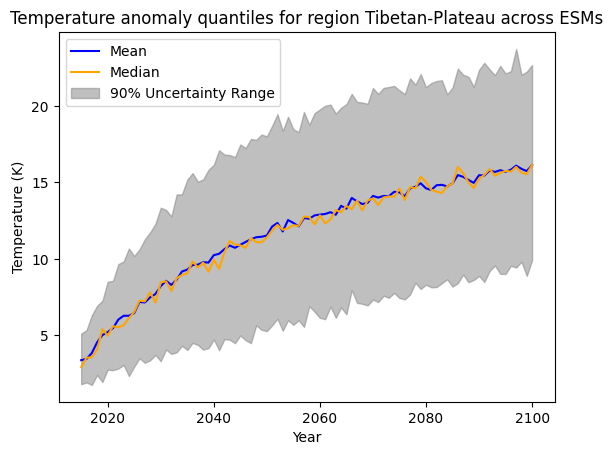

In [ ]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range for a selected region
# across ESMs
example_data = xr.open_dataset(f"{processed_dir}/tas_H_METEOR_regional_quantiles-across-ESM.nc")
sel_mask = selected_regions[1]  # selecting a region
region_name = regionmask.defined_regions.ar6.land[sel_mask].name # getting the name of the region

plt.figure()
plt.plot(example_data['year'].values, example_data['tas_mean'].sel(mask = sel_mask).values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data['tas'].sel(mask = sel_mask, quantile=0.5).values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data['tas'].sel(mask = sel_mask, quantile=0.05).values,
                 example_data['tas'].sel(mask = sel_mask, quantile=0.95).values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')  # Assuming the data is temperature in Kelvin
plt.title(f'Temperature anomaly quantiles for region {region_name} across ESMs')
plt.legend()
plt.show()
plt.savefig(f"../figures/METEOR_cross-ESM_{scenarios_short[s_idx]}_tasanom_quantiles_region{region_name}.png")

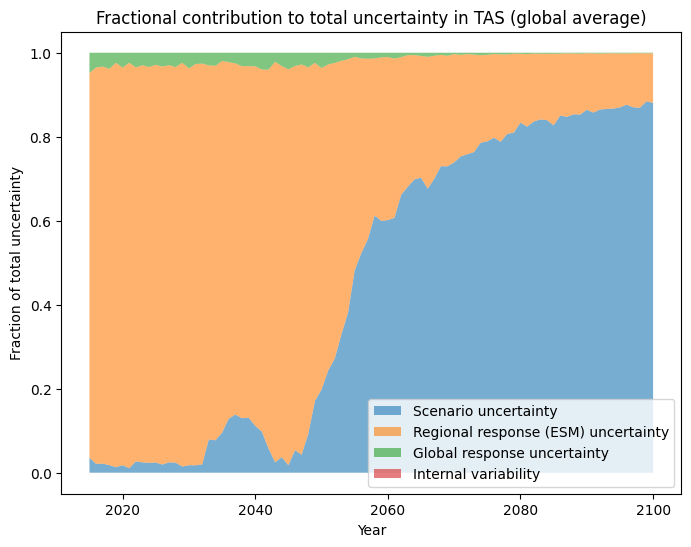

In [ ]:
# plot across-scenario uncertainty components for the selected region and ESM
u_regional_df = xr.open_dataset(f"{processed_dir}/tas_cross-scenario_METEOR_regional_across-scenario-uncertainty.nc")
# computing the total variance as the sum of the individual variances
u_regional_df['var_total'] = u_regional_df['var_scenario'] + u_regional_df['var_esm'] + u_regional_df['var_glb'] + u_regional_df['var_int']

sel_region = -1  # global
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_glb'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title('Fractional contribution to total uncertainty in TAS (global average)')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()
plt.savefig(f"../figures/METEOR_cross-ESM_{scenarios_short[s_idx]}_uncertainty_decomposition_region{region_name}.png")

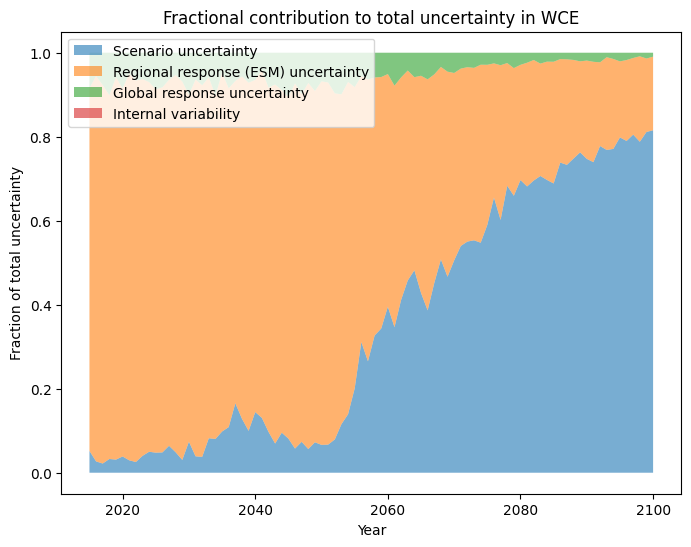

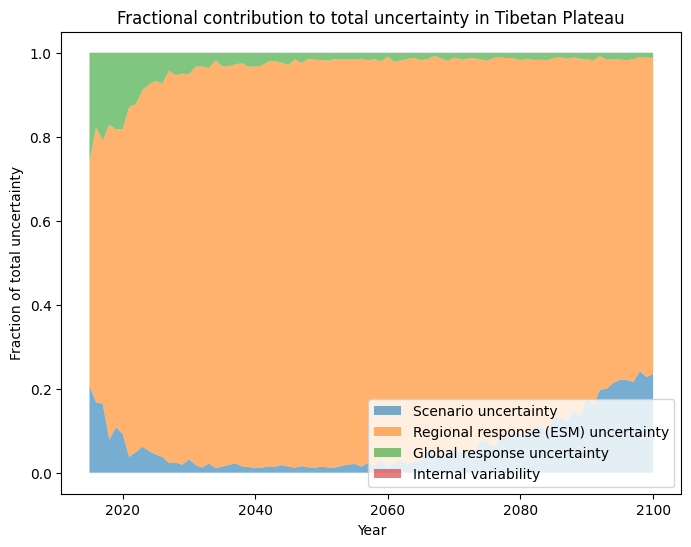

In [ ]:
# the resulting plot can vary by region and in, particular,
# the smallter the region, the larger the contribution of internal variability
sel_region = 17  # CENTRAL EUROPE
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_glb'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title('Fractional contribution to total uncertainty in WCE')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'upper left')
plt.show()
plt.savefig(f"../figures/METEOR_cross-ESM_{scenarios_short[s_idx]}_uncertainty_decomposition_region{region_name}.png")

sel_region = 34  # Tibetan Plateau
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_glb'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title('Fractional contribution to total uncertainty in Tibetan Plateau')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()
plt.savefig(f"../figures/METEOR_cross-ESM_{scenarios_short[s_idx]}_uncertainty_decomposition_region{region_name}.png")